In [1]:
import numpy as np
import os 
import cv2
import random
import pandas as pd
import os
import cv2
import random
from pandas import read_excel
from pandas import DataFrame
from sklearn.decomposition import PCA
import numpy as np
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.multioutput import MultiOutputRegressor
import pickle
import matplotlib.pyplot as plt
from functions import *

In [2]:
path_in = "./video_train"
path_out = "./Cropping/image_cropping"

In [3]:
videos = []
for video in os.listdir(path_in+"/"):
    videos.append(video)
print(videos)
print(len(videos))

['rl1_pb12-4.mp4', 'rl1_pb17-4.mp4', 'rl1_pb19-4.mp4', 'rl1_pb2-4.mp4', 'rl1_pb30-4.mp4', 'rl1_pb4-4.mp4', 'rl1_pb9-4.mp4', 'rl3_pb12-4.mp4', 'rl3_pb16-4.mp4', 'rl3_pb19-4.mp4', 'rl3_pb30-4.mp4', 'rl3_pb4-4.mp4', 'rl3_pb9-4.mp4', 'rl3_pb9-5.mp4', 'rl4_pb16-4.mp4', 'rl4_pb17-4.mp4', 'rl4_pb19-4.mp4', 'rl4_pb2-4.mp4', 'rl4_pb23-4.mp4', 'rl4_pb30-4.mp4', 'rl4_pb4-4.mp4', 'rl4_pb8-7.mp4', 'rl4_pb9-4.mp4', 'rl4_pb9-5.mp4']
24


In [4]:
def cropImages(image,n,m):
    L=list()
    h,w,c=image.shape
    print(h,w)
    newH=int(h/n)
    newW=int(w/m)
    for i in range(n):
        for j in range(m):
            I=image[newH*i:newH*i+newH,newW*j:newW*j+newW]
            L.append(I)
    return L

In [5]:
#Extract images
def extractImages(pathIn,pathOut):
    images = []
    count = 0
    vidcap = cv2.VideoCapture(pathIn)
    print(pathOut)
    vid= pathIn.split("/")[2].split(".")[0]
    success = True
    while success:
        image_augmented = []
        vidcap.set(cv2.CAP_PROP_POS_MSEC,(count*500)) # added this line
        success,image = vidcap.read()        
        if(success != False):
            image_origin = image.copy()
            crop_image_origin = crop_image_from_center(image_origin,360,360)
            image_augmented.append(crop_image_origin)
            image = crop_image_from_center(image,720,720)
            crop_image = cropImages(image,2,2)
            for i in crop_image:
                image_augmented.append(i)
            if(os.path.exists(pathOut)==False):
                os.mkdir(pathOut)
            c=0
            for i in image_augmented:
                pathToSave= pathOut + "/" + vid+"-"+str(count)+"-"+str(c)+".jpg"
                cv2.imwrite(pathToSave,i) # save frame as JPEG file
                print("frame "+vid+"-"+str(count)+"-"+str(c)+".jpg",success) 
                c=c+1
        count = count+1 

In [6]:
for video in videos :
    extractImages(path_in+"/"+video, path_out+"/"+video.replace("mp4",""))

./Cropping/image_cropping/rl1_pb12-4.
720 720
frame rl1_pb12-4-0-0.jpg True
frame rl1_pb12-4-0-1.jpg True
frame rl1_pb12-4-0-2.jpg True
frame rl1_pb12-4-0-3.jpg True
frame rl1_pb12-4-0-4.jpg True
720 720
frame rl1_pb12-4-1-0.jpg True
frame rl1_pb12-4-1-1.jpg True
frame rl1_pb12-4-1-2.jpg True
frame rl1_pb12-4-1-3.jpg True
frame rl1_pb12-4-1-4.jpg True
720 720
frame rl1_pb12-4-2-0.jpg True
frame rl1_pb12-4-2-1.jpg True
frame rl1_pb12-4-2-2.jpg True
frame rl1_pb12-4-2-3.jpg True
frame rl1_pb12-4-2-4.jpg True
720 720
frame rl1_pb12-4-3-0.jpg True
frame rl1_pb12-4-3-1.jpg True
frame rl1_pb12-4-3-2.jpg True
frame rl1_pb12-4-3-3.jpg True
frame rl1_pb12-4-3-4.jpg True
720 720
frame rl1_pb12-4-4-0.jpg True
frame rl1_pb12-4-4-1.jpg True
frame rl1_pb12-4-4-2.jpg True
frame rl1_pb12-4-4-3.jpg True
frame rl1_pb12-4-4-4.jpg True
720 720
frame rl1_pb12-4-5-0.jpg True
frame rl1_pb12-4-5-1.jpg True
frame rl1_pb12-4-5-2.jpg True
frame rl1_pb12-4-5-3.jpg True
frame rl1_pb12-4-5-4.jpg True
720 720
frame 

720 720
frame rl1_pb12-4-51-0.jpg True
frame rl1_pb12-4-51-1.jpg True
frame rl1_pb12-4-51-2.jpg True
frame rl1_pb12-4-51-3.jpg True
frame rl1_pb12-4-51-4.jpg True
720 720
frame rl1_pb12-4-52-0.jpg True
frame rl1_pb12-4-52-1.jpg True
frame rl1_pb12-4-52-2.jpg True
frame rl1_pb12-4-52-3.jpg True
frame rl1_pb12-4-52-4.jpg True
720 720
frame rl1_pb12-4-53-0.jpg True
frame rl1_pb12-4-53-1.jpg True
frame rl1_pb12-4-53-2.jpg True
frame rl1_pb12-4-53-3.jpg True
frame rl1_pb12-4-53-4.jpg True
720 720
frame rl1_pb12-4-54-0.jpg True
frame rl1_pb12-4-54-1.jpg True
frame rl1_pb12-4-54-2.jpg True
frame rl1_pb12-4-54-3.jpg True
frame rl1_pb12-4-54-4.jpg True
720 720
frame rl1_pb12-4-55-0.jpg True
frame rl1_pb12-4-55-1.jpg True
frame rl1_pb12-4-55-2.jpg True
frame rl1_pb12-4-55-3.jpg True
frame rl1_pb12-4-55-4.jpg True
720 720
frame rl1_pb12-4-56-0.jpg True
frame rl1_pb12-4-56-1.jpg True
frame rl1_pb12-4-56-2.jpg True
frame rl1_pb12-4-56-3.jpg True
frame rl1_pb12-4-56-4.jpg True
720 720
frame rl1_pb12

720 720
frame rl1_pb17-4-31-0.jpg True
frame rl1_pb17-4-31-1.jpg True
frame rl1_pb17-4-31-2.jpg True
frame rl1_pb17-4-31-3.jpg True
frame rl1_pb17-4-31-4.jpg True
720 720
frame rl1_pb17-4-32-0.jpg True
frame rl1_pb17-4-32-1.jpg True
frame rl1_pb17-4-32-2.jpg True
frame rl1_pb17-4-32-3.jpg True
frame rl1_pb17-4-32-4.jpg True
720 720
frame rl1_pb17-4-33-0.jpg True
frame rl1_pb17-4-33-1.jpg True
frame rl1_pb17-4-33-2.jpg True
frame rl1_pb17-4-33-3.jpg True
frame rl1_pb17-4-33-4.jpg True
720 720
frame rl1_pb17-4-34-0.jpg True
frame rl1_pb17-4-34-1.jpg True
frame rl1_pb17-4-34-2.jpg True
frame rl1_pb17-4-34-3.jpg True
frame rl1_pb17-4-34-4.jpg True
720 720
frame rl1_pb17-4-35-0.jpg True
frame rl1_pb17-4-35-1.jpg True
frame rl1_pb17-4-35-2.jpg True
frame rl1_pb17-4-35-3.jpg True
frame rl1_pb17-4-35-4.jpg True
720 720
frame rl1_pb17-4-36-0.jpg True
frame rl1_pb17-4-36-1.jpg True
frame rl1_pb17-4-36-2.jpg True
frame rl1_pb17-4-36-3.jpg True
frame rl1_pb17-4-36-4.jpg True
720 720
frame rl1_pb17

720 720
frame rl1_pb19-4-15-0.jpg True
frame rl1_pb19-4-15-1.jpg True
frame rl1_pb19-4-15-2.jpg True
frame rl1_pb19-4-15-3.jpg True
frame rl1_pb19-4-15-4.jpg True
720 720
frame rl1_pb19-4-16-0.jpg True
frame rl1_pb19-4-16-1.jpg True
frame rl1_pb19-4-16-2.jpg True
frame rl1_pb19-4-16-3.jpg True
frame rl1_pb19-4-16-4.jpg True
720 720
frame rl1_pb19-4-17-0.jpg True
frame rl1_pb19-4-17-1.jpg True
frame rl1_pb19-4-17-2.jpg True
frame rl1_pb19-4-17-3.jpg True
frame rl1_pb19-4-17-4.jpg True
720 720
frame rl1_pb19-4-18-0.jpg True
frame rl1_pb19-4-18-1.jpg True
frame rl1_pb19-4-18-2.jpg True
frame rl1_pb19-4-18-3.jpg True
frame rl1_pb19-4-18-4.jpg True
720 720
frame rl1_pb19-4-19-0.jpg True
frame rl1_pb19-4-19-1.jpg True
frame rl1_pb19-4-19-2.jpg True
frame rl1_pb19-4-19-3.jpg True
frame rl1_pb19-4-19-4.jpg True
720 720
frame rl1_pb19-4-20-0.jpg True
frame rl1_pb19-4-20-1.jpg True
frame rl1_pb19-4-20-2.jpg True
frame rl1_pb19-4-20-3.jpg True
frame rl1_pb19-4-20-4.jpg True
720 720
frame rl1_pb19

720 720
frame rl1_pb2-4-2-0.jpg True
frame rl1_pb2-4-2-1.jpg True
frame rl1_pb2-4-2-2.jpg True
frame rl1_pb2-4-2-3.jpg True
frame rl1_pb2-4-2-4.jpg True
720 720
frame rl1_pb2-4-3-0.jpg True
frame rl1_pb2-4-3-1.jpg True
frame rl1_pb2-4-3-2.jpg True
frame rl1_pb2-4-3-3.jpg True
frame rl1_pb2-4-3-4.jpg True
720 720
frame rl1_pb2-4-4-0.jpg True
frame rl1_pb2-4-4-1.jpg True
frame rl1_pb2-4-4-2.jpg True
frame rl1_pb2-4-4-3.jpg True
frame rl1_pb2-4-4-4.jpg True
720 720
frame rl1_pb2-4-5-0.jpg True
frame rl1_pb2-4-5-1.jpg True
frame rl1_pb2-4-5-2.jpg True
frame rl1_pb2-4-5-3.jpg True
frame rl1_pb2-4-5-4.jpg True
720 720
frame rl1_pb2-4-6-0.jpg True
frame rl1_pb2-4-6-1.jpg True
frame rl1_pb2-4-6-2.jpg True
frame rl1_pb2-4-6-3.jpg True
frame rl1_pb2-4-6-4.jpg True
720 720
frame rl1_pb2-4-7-0.jpg True
frame rl1_pb2-4-7-1.jpg True
frame rl1_pb2-4-7-2.jpg True
frame rl1_pb2-4-7-3.jpg True
frame rl1_pb2-4-7-4.jpg True
720 720
frame rl1_pb2-4-8-0.jpg True
frame rl1_pb2-4-8-1.jpg True
frame rl1_pb2-4-

...

720 720
frame rl4_pb30-4-52-0.jpg True
frame rl4_pb30-4-52-1.jpg True
frame rl4_pb30-4-52-2.jpg True
frame rl4_pb30-4-52-3.jpg True
frame rl4_pb30-4-52-4.jpg True
720 720
frame rl4_pb30-4-53-0.jpg True
frame rl4_pb30-4-53-1.jpg True
frame rl4_pb30-4-53-2.jpg True
frame rl4_pb30-4-53-3.jpg True
frame rl4_pb30-4-53-4.jpg True
720 720
frame rl4_pb30-4-54-0.jpg True
frame rl4_pb30-4-54-1.jpg True
frame rl4_pb30-4-54-2.jpg True
frame rl4_pb30-4-54-3.jpg True
frame rl4_pb30-4-54-4.jpg True
720 720
frame rl4_pb30-4-55-0.jpg True
frame rl4_pb30-4-55-1.jpg True
frame rl4_pb30-4-55-2.jpg True
frame rl4_pb30-4-55-3.jpg True
frame rl4_pb30-4-55-4.jpg True
720 720
frame rl4_pb30-4-56-0.jpg True
frame rl4_pb30-4-56-1.jpg True
frame rl4_pb30-4-56-2.jpg True
frame rl4_pb30-4-56-3.jpg True
frame rl4_pb30-4-56-4.jpg True
720 720
frame rl4_pb30-4-57-0.jpg True
frame rl4_pb30-4-57-1.jpg True
frame rl4_pb30-4-57-2.jpg True
frame rl4_pb30-4-57-3.jpg True
frame rl4_pb30-4-57-4.jpg True
720 720
frame rl4_pb30

720 720
frame rl4_pb4-4-41-0.jpg True
frame rl4_pb4-4-41-1.jpg True
frame rl4_pb4-4-41-2.jpg True
frame rl4_pb4-4-41-3.jpg True
frame rl4_pb4-4-41-4.jpg True
720 720
frame rl4_pb4-4-42-0.jpg True
frame rl4_pb4-4-42-1.jpg True
frame rl4_pb4-4-42-2.jpg True
frame rl4_pb4-4-42-3.jpg True
frame rl4_pb4-4-42-4.jpg True
720 720
frame rl4_pb4-4-43-0.jpg True
frame rl4_pb4-4-43-1.jpg True
frame rl4_pb4-4-43-2.jpg True
frame rl4_pb4-4-43-3.jpg True
frame rl4_pb4-4-43-4.jpg True
720 720
frame rl4_pb4-4-44-0.jpg True
frame rl4_pb4-4-44-1.jpg True
frame rl4_pb4-4-44-2.jpg True
frame rl4_pb4-4-44-3.jpg True
frame rl4_pb4-4-44-4.jpg True
720 720
frame rl4_pb4-4-45-0.jpg True
frame rl4_pb4-4-45-1.jpg True
frame rl4_pb4-4-45-2.jpg True
frame rl4_pb4-4-45-3.jpg True
frame rl4_pb4-4-45-4.jpg True
720 720
frame rl4_pb4-4-46-0.jpg True
frame rl4_pb4-4-46-1.jpg True
frame rl4_pb4-4-46-2.jpg True
frame rl4_pb4-4-46-3.jpg True
frame rl4_pb4-4-46-4.jpg True
720 720
frame rl4_pb4-4-47-0.jpg True
frame rl4_pb4-

720 720
frame rl4_pb8-7-31-0.jpg True
frame rl4_pb8-7-31-1.jpg True
frame rl4_pb8-7-31-2.jpg True
frame rl4_pb8-7-31-3.jpg True
frame rl4_pb8-7-31-4.jpg True
720 720
frame rl4_pb8-7-32-0.jpg True
frame rl4_pb8-7-32-1.jpg True
frame rl4_pb8-7-32-2.jpg True
frame rl4_pb8-7-32-3.jpg True
frame rl4_pb8-7-32-4.jpg True
720 720
frame rl4_pb8-7-33-0.jpg True
frame rl4_pb8-7-33-1.jpg True
frame rl4_pb8-7-33-2.jpg True
frame rl4_pb8-7-33-3.jpg True
frame rl4_pb8-7-33-4.jpg True
720 720
frame rl4_pb8-7-34-0.jpg True
frame rl4_pb8-7-34-1.jpg True
frame rl4_pb8-7-34-2.jpg True
frame rl4_pb8-7-34-3.jpg True
frame rl4_pb8-7-34-4.jpg True
720 720
frame rl4_pb8-7-35-0.jpg True
frame rl4_pb8-7-35-1.jpg True
frame rl4_pb8-7-35-2.jpg True
frame rl4_pb8-7-35-3.jpg True
frame rl4_pb8-7-35-4.jpg True
720 720
frame rl4_pb8-7-36-0.jpg True
frame rl4_pb8-7-36-1.jpg True
frame rl4_pb8-7-36-2.jpg True
frame rl4_pb8-7-36-3.jpg True
frame rl4_pb8-7-36-4.jpg True
720 720
frame rl4_pb8-7-37-0.jpg True
frame rl4_pb8-

720 720
frame rl4_pb9-4-23-0.jpg True
frame rl4_pb9-4-23-1.jpg True
frame rl4_pb9-4-23-2.jpg True
frame rl4_pb9-4-23-3.jpg True
frame rl4_pb9-4-23-4.jpg True
720 720
frame rl4_pb9-4-24-0.jpg True
frame rl4_pb9-4-24-1.jpg True
frame rl4_pb9-4-24-2.jpg True
frame rl4_pb9-4-24-3.jpg True
frame rl4_pb9-4-24-4.jpg True
720 720
frame rl4_pb9-4-25-0.jpg True
frame rl4_pb9-4-25-1.jpg True
frame rl4_pb9-4-25-2.jpg True
frame rl4_pb9-4-25-3.jpg True
frame rl4_pb9-4-25-4.jpg True
720 720
frame rl4_pb9-4-26-0.jpg True
frame rl4_pb9-4-26-1.jpg True
frame rl4_pb9-4-26-2.jpg True
frame rl4_pb9-4-26-3.jpg True
frame rl4_pb9-4-26-4.jpg True
720 720
frame rl4_pb9-4-27-0.jpg True
frame rl4_pb9-4-27-1.jpg True
frame rl4_pb9-4-27-2.jpg True
frame rl4_pb9-4-27-3.jpg True
frame rl4_pb9-4-27-4.jpg True
720 720
frame rl4_pb9-4-28-0.jpg True
frame rl4_pb9-4-28-1.jpg True
frame rl4_pb9-4-28-2.jpg True
frame rl4_pb9-4-28-3.jpg True
frame rl4_pb9-4-28-4.jpg True
720 720
frame rl4_pb9-4-29-0.jpg True
frame rl4_pb9-

720 720
frame rl4_pb9-5-11-0.jpg True
frame rl4_pb9-5-11-1.jpg True
frame rl4_pb9-5-11-2.jpg True
frame rl4_pb9-5-11-3.jpg True
frame rl4_pb9-5-11-4.jpg True
720 720
frame rl4_pb9-5-12-0.jpg True
frame rl4_pb9-5-12-1.jpg True
frame rl4_pb9-5-12-2.jpg True
frame rl4_pb9-5-12-3.jpg True
frame rl4_pb9-5-12-4.jpg True
720 720
frame rl4_pb9-5-13-0.jpg True
frame rl4_pb9-5-13-1.jpg True
frame rl4_pb9-5-13-2.jpg True
frame rl4_pb9-5-13-3.jpg True
frame rl4_pb9-5-13-4.jpg True
720 720
frame rl4_pb9-5-14-0.jpg True
frame rl4_pb9-5-14-1.jpg True
frame rl4_pb9-5-14-2.jpg True
frame rl4_pb9-5-14-3.jpg True
frame rl4_pb9-5-14-4.jpg True
720 720
frame rl4_pb9-5-15-0.jpg True
frame rl4_pb9-5-15-1.jpg True
frame rl4_pb9-5-15-2.jpg True
frame rl4_pb9-5-15-3.jpg True
frame rl4_pb9-5-15-4.jpg True
720 720
frame rl4_pb9-5-16-0.jpg True
frame rl4_pb9-5-16-1.jpg True
frame rl4_pb9-5-16-2.jpg True
frame rl4_pb9-5-16-3.jpg True
frame rl4_pb9-5-16-4.jpg True
720 720
frame rl4_pb9-5-17-0.jpg True
frame rl4_pb9-

In [7]:
train_path = "./Cropping/image_cropping"

In [8]:
train_dir = os.listdir(train_path)
train_names =[]
for i in train_dir:
    train_names.append(os.listdir(train_path+"/"+i))
train_dir

['rl1_pb12-4',
 'rl1_pb17-4',
 'rl1_pb19-4',
 'rl1_pb2-4',
 'rl1_pb30-4',
 'rl1_pb4-4',
 'rl1_pb9-4',
 'rl3_pb12-4',
 'rl3_pb16-4',
 'rl3_pb19-4',
 'rl3_pb30-4',
 'rl3_pb4-4',
 'rl3_pb9-4',
 'rl3_pb9-5',
 'rl4_pb16-4',
 'rl4_pb17-4',
 'rl4_pb19-4',
 'rl4_pb2-4',
 'rl4_pb23-4',
 'rl4_pb30-4',
 'rl4_pb4-4',
 'rl4_pb8-7',
 'rl4_pb9-4',
 'rl4_pb9-5']

In [9]:
#same Teneurs for each image:
import os
import pandas as pd
def prepareFileAugm(Cu_r, Fe_r, Pb_r, Zn_r):
    dictt = {}
    writer = pd.ExcelWriter("./Cropping/Teneurs/data_train_augm_Pb.xlsx", engine = 'xlsxwriter')
    
    file_name = './Teneurs/DataSource.xlsx' # name of your excel file
    
    df = pd.read_excel(file_name, sheet_name = 'Relavage Pb')
    name_video=df["points"]
    Analyses = {"points": [],
        "Cu (%)": [],
        "Fe (%)": [],
        "Pb (%)": [],
        "Zn (%)": []
    }
    for video in videos:
        df_row= df[df['points']== video ]
        if not "-" in video:
            break
        video_0, video_1 = video.split(".")[0].split("-")
        for train_name in train_names:
            for train_image in train_name:
                if(train_image != "desktop.ini"):
                    train_0, train_1, train_2, _ = train_image.split(".")[0].split("-")
                    if(video_0 == train_0)and (video_1 == train_1):
                        Analyses["points"].append(train_image)
                        Analyses["Cu (%)"].append(df_row["Cu (%)"].to_string(index=False))
                        Analyses["Fe (%)"].append(df_row["Fe (%)"].to_string(index=False))
                        Analyses["Pb (%)"].append(df_row["Pb (%)"].to_string(index=False))
                        Analyses["Zn (%)"].append(df_row["Zn (%)"].to_string(index=False))
                    dictt[train_2] = [train_image for train_image in train_name if train_image.split(".")[0].split("-")[2]==train_2]

    df_Pb = pd.DataFrame(Analyses, columns= ['points', 'Cu (%)', 'Fe (%)', 'Pb (%)', 'Zn (%)']) 
    print(df_Pb)
    for key,value in dictt.items():
        ofsset_cu = random.uniform(-1, Cu_r) 
        ofsset_fe = random.uniform(-1, Fe_r)
        ofsset_pb = random.uniform(-1, Pb_r)
        ofsset_zn = random.uniform(-1, Zn_r)
        for i in range(0,df_Pb.shape[0]):
            cu = float(df_Pb.iloc[i]['Cu (%)'])
            fe = float(df_Pb.iloc[i]['Fe (%)'])
            pb = float(df_Pb.iloc[i]['Pb (%)'])
            zn = float(df_Pb.iloc[i]['Zn (%)'])
            if(df_Pb['points'][i].split('.')[0].split('-')[2] == key): 
                df_Pb['Cu (%)'][i] = cu + ofsset_cu
                df_Pb['Fe (%)'][i] = fe + ofsset_fe
                df_Pb['Pb (%)'][i] = pb + ofsset_pb
                df_Pb['Zn (%)'][i] = zn + ofsset_zn
    df_Pb.to_excel(writer, index = None, header=True)
    
    writer.save()
    writer.close()        

In [10]:
Cu_r, Fe_r, Pb_r, Zn_r = 1, 1, 1, 1

In [11]:
prepareFileAugm(Cu_r, Fe_r, Pb_r, Zn_r)

                  points Cu (%) Fe (%) Pb (%) Zn (%)
0     rl1_pb12-4-0-0.jpg   1.77  18.18  15.96   5.83
1     rl1_pb12-4-0-1.jpg   1.77  18.18  15.96   5.83
2     rl1_pb12-4-0-2.jpg   1.77  18.18  15.96   5.83
3     rl1_pb12-4-0-3.jpg   1.77  18.18  15.96   5.83
4     rl1_pb12-4-0-4.jpg   1.77  18.18  15.96   5.83
...                  ...    ...    ...    ...    ...
7785   rl4_pb9-5-9-0.jpg   1.29   6.96  57.28   2.22
7786   rl4_pb9-5-9-1.jpg   1.29   6.96  57.28   2.22
7787   rl4_pb9-5-9-2.jpg   1.29   6.96  57.28   2.22
7788   rl4_pb9-5-9-3.jpg   1.29   6.96  57.28   2.22
7789   rl4_pb9-5-9-4.jpg   1.29   6.96  57.28   2.22

[7790 rows x 5 columns]


C:\Users\Hanane Bouidia\anaconda3\lib\site-packages\xlsxwriter\workbook.py:339: UserWarning: Calling close() on already closed file.
  warn("Calling close() on already closed file.")


In [12]:
file_name = './Cropping/Teneurs/data_train_augm_Pb.xlsx'
df = read_excel(file_name)
df

,points,Cu (%),Fe (%),Pb (%),Zn (%)
0,rl1_pb12-4-0-0.jpg,1.791250,18.962765,16.554946,6.366869
1,rl1_pb12-4-0-1.jpg,1.791250,18.962765,16.554946,6.366869
2,rl1_pb12-4-0-2.jpg,1.791250,18.962765,16.554946,6.366869
3,rl1_pb12-4-0-3.jpg,1.791250,18.962765,16.554946,6.366869
4,rl1_pb12-4-0-4.jpg,1.791250,18.962765,16.554946,6.366869
...,...,...,...,...,...
7785,rl4_pb9-5-9-0.jpg,1.203778,6.062870,56.704295,1.582042
7786,rl4_pb9-5-9-1.jpg,1.203778,6.062870,56.704295,1.582042
7787,rl4_pb9-5-9-2.jpg,1.203778,6.062870,56.704295,1.582042
7788,rl4_pb9-5-9-3.jpg,1.203778,6.062870,56.704295,1.582042


In [13]:
fft_features = []
labels_cu = []
labels_pb = []
labels_fe = []
labels_zn = []

In [14]:
for line in df.values:
    for i in train_dir:
        path_dir = train_path+"/"+i
        if(i.split('-')[0] == line[0].split('.')[0].split('-')[0] and i.split('-')[1] == line[0].split('.')[0].split('-')[1]):
            image = cv2.imread(path_dir+"/"+line[0])
            fft_pca = image_to_fft_pca(image)
            fft_features.append(fft_pca)
            labels_cu.append(line[1])
            labels_fe.append(line[2])
            labels_pb.append(line[3])
            labels_zn.append(line[4])

In [15]:
fft_features = np.array(fft_features)
labels_cu = np.array(labels_cu)
labels_fe = np.array(labels_fe)
labels_pb = np.array(labels_pb)
labels_zn = np.array(labels_zn)

In [16]:
fft_features

array([[-15.31589623, -15.24072644, -14.65799519, ..., -16.11757167,
        -14.65799519, -15.24072644],
       [-14.26748172, -16.3896696 , -15.97053931, ..., -15.55313425,
        -15.97053931, -16.3896696 ],
       [-14.40109564, -14.67343086, -15.18095392, ..., -14.28161472,
        -15.18095392, -14.67343086],
       ...,
       [-17.86619081, -19.70315498, -18.81853044, ..., -19.74830437,
        -18.81853044, -19.70315498],
       [-18.63130959, -17.1010047 , -17.99132083, ..., -18.94687448,
        -17.99132083, -17.1010047 ],
       [-18.98282196, -17.99359382, -19.1081727 , ..., -17.95112571,
        -19.1081727 , -17.99359382]])

In [17]:
fft_features.shape

(7790, 360)

In [18]:
labels_cu.shape, labels_fe.shape, labels_pb.shape, labels_zn.shape

((7790,), (7790,), (7790,), (7790,))

In [19]:
labels = np.array([labels_cu, labels_fe, labels_pb, labels_zn]).T

In [20]:
labels.shape

(7790, 4)

In [21]:
svm = SVR()
msvm = MultiOutputRegressor(svm)
msvm.fit(fft_features, labels)

MultiOutputRegressor(estimator=SVR())

# Test Data

In [22]:
path_test_in = "./video_test"
path_test_out = "./Cropping/image_test"

In [23]:
videos_test = []
for video_test in os.listdir(path_test_in+"/"):
    videos_test.append(video_test)
print(videos_test)
print(len(videos_test))

['rl1_pb16-4.mp4', 'rl1_pb9-5.mp4', 'rl3_pb2-4.mp4', 'rl3_pb23-4.mp4', 'rl4_pb12-4.mp4', 'rl4_pb30-6.mp4']
6


In [24]:
#Extract test images
def extractImages(pathIn,pathOut):
    images = []
    count = 0
    vidcap = cv2.VideoCapture(pathIn)
    print(pathOut)
    vid= pathIn.split("/")[2].split(".")[0]
    success = True
    while success:
        image_augmented = []
        vidcap.set(cv2.CAP_PROP_POS_MSEC,(count*500)) # added this line
        success,image = vidcap.read()        
        if(success != False):
            image = crop_image_from_center(image,360,360)
            if(os.path.exists(pathOut)==False):
                os.mkdir(pathOut)
            pathToSave= pathOut + "/" + vid+"-"+str(count)+".jpg"
            cv2.imwrite(pathToSave,image) # save frame as JPEG file
            print("frame "+vid+"-"+str(count)+".jpg",success) 
        count = count+1 

In [25]:
for video_test in videos_test :
    extractImages(path_test_in+"/"+video_test, path_test_out+"/"+video_test.replace("mp4",""))

./Cropping/image_test/rl1_pb16-4.
frame rl1_pb16-4-0.jpg True
frame rl1_pb16-4-1.jpg True
frame rl1_pb16-4-2.jpg True
frame rl1_pb16-4-3.jpg True
frame rl1_pb16-4-4.jpg True
frame rl1_pb16-4-5.jpg True
frame rl1_pb16-4-6.jpg True
frame rl1_pb16-4-7.jpg True
frame rl1_pb16-4-8.jpg True
frame rl1_pb16-4-9.jpg True
frame rl1_pb16-4-10.jpg True
frame rl1_pb16-4-11.jpg True
frame rl1_pb16-4-12.jpg True
frame rl1_pb16-4-13.jpg True
frame rl1_pb16-4-14.jpg True
frame rl1_pb16-4-15.jpg True
frame rl1_pb16-4-16.jpg True
frame rl1_pb16-4-17.jpg True
frame rl1_pb16-4-18.jpg True
frame rl1_pb16-4-19.jpg True
frame rl1_pb16-4-20.jpg True
frame rl1_pb16-4-21.jpg True
frame rl1_pb16-4-22.jpg True
frame rl1_pb16-4-23.jpg True
frame rl1_pb16-4-24.jpg True
frame rl1_pb16-4-25.jpg True
frame rl1_pb16-4-26.jpg True
frame rl1_pb16-4-27.jpg True
frame rl1_pb16-4-28.jpg True
frame rl1_pb16-4-29.jpg True
frame rl1_pb16-4-30.jpg True
frame rl1_pb16-4-31.jpg True
frame rl1_pb16-4-32.jpg True
frame rl1_pb16-4-33

frame rl4_pb12-4-31.jpg True
frame rl4_pb12-4-32.jpg True
frame rl4_pb12-4-33.jpg True
frame rl4_pb12-4-34.jpg True
frame rl4_pb12-4-35.jpg True
frame rl4_pb12-4-36.jpg True
frame rl4_pb12-4-37.jpg True
frame rl4_pb12-4-38.jpg True
frame rl4_pb12-4-39.jpg True
frame rl4_pb12-4-40.jpg True
frame rl4_pb12-4-41.jpg True
frame rl4_pb12-4-42.jpg True
frame rl4_pb12-4-43.jpg True
frame rl4_pb12-4-44.jpg True
frame rl4_pb12-4-45.jpg True
frame rl4_pb12-4-46.jpg True
frame rl4_pb12-4-47.jpg True
frame rl4_pb12-4-48.jpg True
frame rl4_pb12-4-49.jpg True
frame rl4_pb12-4-50.jpg True
frame rl4_pb12-4-51.jpg True
frame rl4_pb12-4-52.jpg True
frame rl4_pb12-4-53.jpg True
frame rl4_pb12-4-54.jpg True
frame rl4_pb12-4-55.jpg True
frame rl4_pb12-4-56.jpg True
frame rl4_pb12-4-57.jpg True
frame rl4_pb12-4-58.jpg True
frame rl4_pb12-4-59.jpg True
frame rl4_pb12-4-60.jpg True
frame rl4_pb12-4-61.jpg True
frame rl4_pb12-4-62.jpg True
frame rl4_pb12-4-63.jpg True
frame rl4_pb12-4-64.jpg True
frame rl4_pb12

In [26]:
import os
import pandas as pd
def prepareFileAugm(Cu_r, Fe_r, Pb_r, Zn_r):
    writer = pd.ExcelWriter('C:/Users/HB/DataAugProject/Rotation_0_45_StableTeneurs/Teneurs/data_test_augm_Pb.xlsx', engine = 'xlsxwriter')
    # load the train dataset pb
    test_path = "C:/Users/HB/DataAugProject/Rotation_0_45_StableTeneurs/image_test"
    test_dir = os.listdir(test_path)
    test_names =[]
    for i in test_dir:
        test_names.append(os.listdir(test_path+"/"+i))
    file_name = 'C:/Users/HB/DataAugProject/Teneurs/DataSource.xlsx' # name of your excel file
    
    df = pd.read_excel(file_name, sheet_name = 'Relavage Pb')
    name_video=df["points"]
    Analyses = {"points": [],
        "Cu (%)": [],
        "Fe (%)": [],
        "Pb (%)": [],
        "Zn (%)": []
    }

    for video_test in videos_test:
        df_row= df[df['points']== video_test ]
        if not "-" in video_test:
            break
        video_0, video_1 = video_test.split(".")[0].split("-")
     
        for test_name in test_names:
            for test_image in test_name:
                if(test_name != "desktop.ini"):
                    train_0, train_1, _, = test_image.split(".")[0].split("-")
                    if(video_0 == train_0)and (video_1 == train_1):
                        Analyses["points"].append(test_image)
                        Analyses["Cu (%)"].append(df_row["Cu (%)"].to_string(index=False))
                        Analyses["Fe (%)"].append(df_row["Fe (%)"].to_string(index=False))
                        Analyses["Pb (%)"].append(df_row["Pb (%)"].to_string(index=False))
                        Analyses["Zn (%)"].append(df_row["Zn (%)"].to_string(index=False))
    df_Pb = pd.DataFrame(Analyses, columns= ['points', 'Cu (%)', 'Fe (%)', 'Pb (%)', 'Zn (%)']) 
    
    for i in range(0,df_Pb.shape[0]):
        cu = float(df_Pb.iloc[i]['Cu (%)'])
        fe = float(df_Pb.iloc[i]['Fe (%)'])
        pb = float(df_Pb.iloc[i]['Pb (%)'])
        zn = float(df_Pb.iloc[i]['Zn (%)'])
        
        ofsset = random.uniform(-1, Cu_r)
        df_Pb.at[i,'Cu (%)'] = cu + ofsset
        ofsset = random.uniform(-1, Fe_r)
        df_Pb.at[i,'Fe (%)'] = fe + ofsset
        ofsset = random.uniform(-1, Pb_r)
        df_Pb.at[i,'Pb (%)'] = pb + ofsset
        ofsset = random.uniform(-1, Zn_r)
        df_Pb.at[i,'Zn (%)'] = zn + ofsset
    df_Pb.to_excel(writer, index = None, header=True)
    
    writer.save()
    writer.close()

In [27]:
Cu_r, Fe_r, Pb_r, Zn_r = 1, 1, 1, 1

In [28]:
#prepareFileAugm(Cu_r, Fe_r, Pb_r, Zn_r)

In [29]:
test_file_name = './data_test_augm_Pb.xlsx'
df_test = read_excel(test_file_name)

In [30]:
df_test

,points,Cu (%),Fe (%),Pb (%),Zn (%)
0,rl1_pb16-4-0.jpg,3.200571,16.987091,22.554969,5.962374
1,rl1_pb16-4-1.jpg,2.585517,16.279429,22.660719,5.848969
2,rl1_pb16-4-10.jpg,3.744854,16.587169,24.287712,6.527869
3,rl1_pb16-4-11.jpg,3.366109,16.795266,22.643737,6.001809
4,rl1_pb16-4-12.jpg,2.145116,16.081933,24.349298,7.018374
...,...,...,...,...,...
385,rl4_pb30-6-60.jpg,1.350626,5.035719,57.539686,0.784360
386,rl4_pb30-6-61.jpg,0.835262,4.947739,57.260277,1.025291
387,rl4_pb30-6-7.jpg,1.978090,6.679091,57.170364,2.111531
388,rl4_pb30-6-8.jpg,2.341759,6.268026,57.352715,0.582520


In [31]:
test_fft_features = []
test_labels_cu = []
test_labels_fe = []
test_labels_pb = []
test_labels_zn = []

In [32]:
test_path = "./Cropping/image_test"
test_dir = os.listdir(test_path)
test_names =[]
for i in test_dir:
    test_names.append(os.listdir(test_path+"/"+i))
test_dir

['rl1_pb16-4',
 'rl1_pb9-5',
 'rl3_pb2-4',
 'rl3_pb23-4',
 'rl4_pb12-4',
 'rl4_pb30-6']

In [33]:
for line in df_test.values:
    for i in test_dir:
        path_dir = test_path+"/"+i
        if(i.split('-')[0] == line[0].split('.')[0].split('-')[0]):
            image = cv2.imread(path_dir+"/"+line[0])
            test_fft_pca = image_to_fft_pca(image)
            test_fft_features.append(test_fft_pca)
            test_labels_cu.append(line[1])
            test_labels_fe.append(line[2])
            test_labels_pb.append(line[3])
            test_labels_zn.append(line[4])

In [34]:
test_fft_features = np.array(test_fft_features)
test_labels_cu = np.array(test_labels_cu)
test_labels_fe = np.array(test_labels_fe)
test_labels_pb = np.array(test_labels_pb)
test_labels_zn = np.array(test_labels_zn)

In [35]:
test_fft_features.shape

(390, 360)

In [36]:
test_labels_cu.shape, test_labels_fe.shape, test_labels_pb.shape, test_labels_zn.shape

((390,), (390,), (390,), (390,))

In [37]:
test_labels = np.array([test_labels_cu, test_labels_fe, test_labels_pb, test_labels_zn]).T

In [38]:
test_labels.shape

(390, 4)

In [39]:
y_pred = msvm.predict(test_fft_features)
print("MAE", mean_absolute_error(test_labels, y_pred))
print("MSE", mean_squared_error(test_labels, y_pred))
print("R2 Score", r2_score(test_labels, y_pred))

MAE 4.9446676396169
MSE 54.71001541771183
R2 Score 0.1730798158722138


# Test Video 1

In [40]:
TeunneurReel = TenneurReel("rl4_pb30-6.mp4", "./Teneurs/DataSource.xlsx")

Teneur predits : [array([[ 1.37197567, 11.02719222, 46.15000184,  4.10338003]]), array([[ 1.07208118,  8.25981469, 47.21137095,  3.37930098]]), array([[ 1.47528556, 11.40599607, 43.64667128,  4.16965799]]), array([[ 1.39498054, 10.82154374, 43.01499618,  3.93212949]]), array([[ 1.37035048, 10.4037944 , 47.0106716 ,  4.26565982]]), array([[ 1.44694729, 11.20370103, 44.47551293,  4.24415875]]), array([[ 1.57401105, 10.96797738, 43.97740661,  4.34025874]]), array([[ 1.41662012, 10.74140898, 44.24813293,  4.04210493]]), array([[ 1.33967372, 10.61822841, 44.604217  ,  3.87218407]]), array([[ 1.48746983, 10.61850658, 43.8886429 ,  4.09127008]]), array([[ 1.48067572, 10.3666063 , 44.28511328,  4.12705494]]), array([[ 1.49408152, 11.52831159, 44.04436586,  4.29455057]]), array([[ 1.44315773, 10.96338864, 46.33651818,  4.27946229]]), array([[ 1.2271969 , 10.57951976, 43.46240169,  3.79460294]]), array([[ 1.26850619, 10.30812855, 45.73284816,  3.92776259]]), array([[ 1.30928051,  9.90191328, 45.

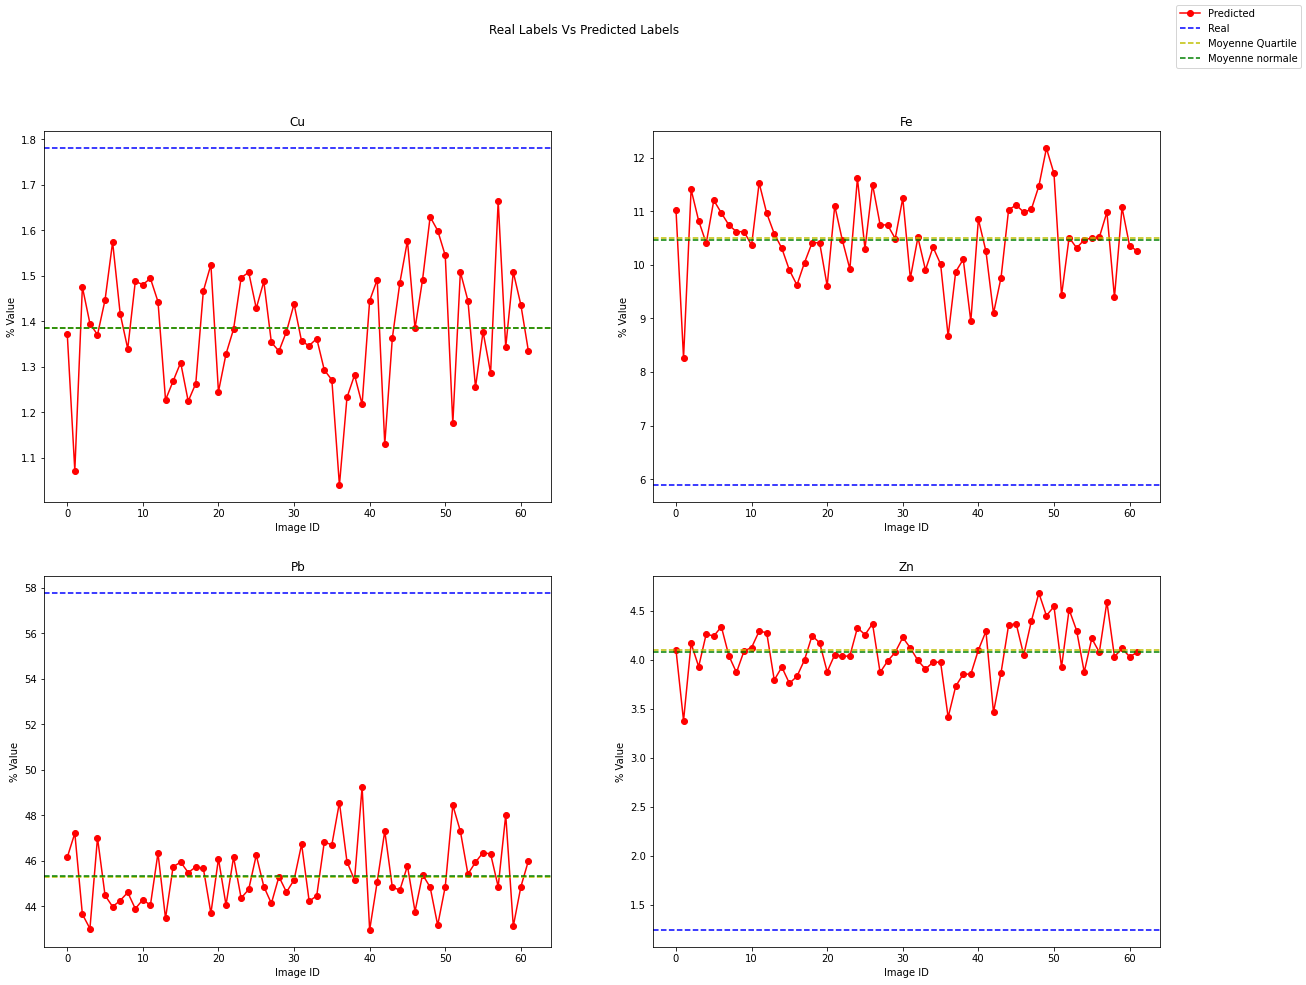

In [41]:
Teneur_predit = predict_video("./video_test/rl4_pb30-6.mp4", msvm)
print("Teneur predits :",Teneur_predit)
Moyenne = CalculMoyenneTenneursPredites(Teneur_predit)
PlotAllTenneurs(Teneur_predit, TeunneurReel, Moyenne)

In [42]:
print(f"Cu: {abs(TeunneurReel[0] - Moyenne[0])}")
print(f"Fe: {abs(TeunneurReel[1] - Moyenne[1])}")
print(f"Pb: {abs(TeunneurReel[2] - Moyenne[2])}")
print(f"Zn: {abs(TeunneurReel[3] - Moyenne[3])}")

Cu: 0.39445261383913865
Fe: 4.618860025546174
Pb: 12.499291494337896
Zn: 2.8671356574070366
